<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Concepts in deep learning</h1>
<p>Every ANN (Artificial Neural Network) consists of inputs and tries to predict the output. In the following equation y denotes the prediction, x is the input data, and w is the weights. w values are learned by the models through back propagation. Back propagation refers to the process of adjusting the weight values based on feedback on the prediction.</p>

$$y=x_{1}\cdot w_{1}+x_{2}\cdot w_{2}+...$$

<p>Equations of this format are not able to deal with non-linear functions, so the right side of the equation is wrapped in a non-linear function, usually denoted as sigma. Sigma can be any nonlinear function, e.g.: log.</p>

$$y=\sigma(x_{1}\cdot w_{1}+x_{2}\cdot w_{2}+...)$$

<p>The idea is having many units forming a network performing the calculations. Deep learning is fundamentally empirical.</p>

<p>The outcome is called a dependent variable, while the set of inputs is called the independent variables.</p>

<h2>Data types</h2>
<p>There are two types of data we need to make difference of:
<ul>
<li><b>Continuous</b>: Data that can be represented by numbers. Many, possibly infinite disticnt value. eg.: height, salary</li>
<li><b>Categorical</b>: Limited distinct values. eg.: Exam result, landscape type, disease diagnosis</li>
</ul>
</p>

<h2>Softmax function</h2>

<p>The softmax function is a strictly positive function. We calculate it with the following formula:</p>

$$\sigma_{i}=\frac{e^{z_{i}}}{\sum_{}^{}e^{z}}$$

<p>Where z is a collection of numbers and i is a data index.<br>Applying the softmax to a series of numbers, the softmax values will sum up to 1. This property makes it suitable for probability calculations.</p>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

array = np.array([1, 2, 3])
softmax = np.exp(array) / np.sum(np.exp(array))

print(softmax)
print(np.sum(softmax))

[0.09003057 0.24472847 0.66524096]
1.0


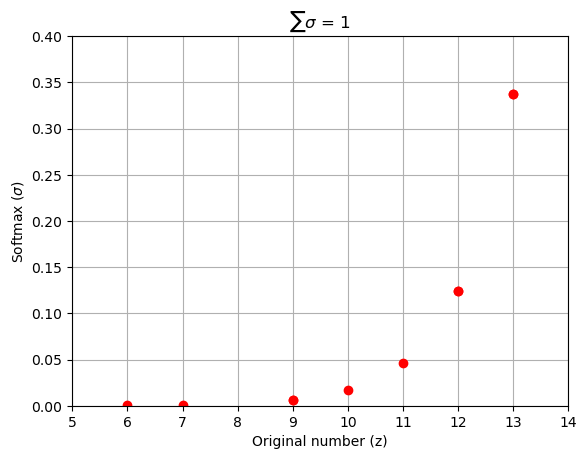

In [3]:
z = np.random.randint(5, 15, 10)
softmax = np.exp(z) / np.sum(np.exp(z))

plt.plot(z, (softmax), 'ro')
plt.xlabel('Original number (z)')
plt.ylabel('Softmax ($\\sigma$)')
plt.title('$\\sum\\sigma$ = %g'%np.sum(softmax))

plt.grid()
plt.xlim((np.min(z) - 1, np.max(z) + 1))
plt.ylim((0, np.round(np.max(softmax), 1) + 0.1))

plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>Entropy</h2>
<p>Entropy quantifies how unpredictable an event is. Low entropy means a predictable system, high entropy is unpredictable. Usually it is denoted as a H.</p>

$$H(p)=-\sum_{i=0}^{n}p(x_{i}) \cdot log_{2}(p(x_{i}))$$

<p>The base of the logarithm is not fixed. If we use 2-based log the units is called bits, if we use ln, it is called nats.</p>
<p>Cross-entropy refers to the relationship between two probability distributions.</p>

$$H(p,q)=-\sum_{i=0}^{n}p(x_{i}) \cdot log_{2}(q(x_{i}))$$

<p>Cross-entropy can be used for measuring the performance of a model. If for example p is the expected output, and q is the actual one.</p>

</div>

In [19]:
p = 0.25 # probability of an event happening

def entropy(p):
    return - p * np.log(p)

H = sum([entropy(p0) for p0 in [p, 1-p]])
print(f'Entropy:              {np.round(H, 4)} nats')

# Cross-entropy
p = [0.9999, 0.0001]
q = [0.25, 0.75]

def crossEntropy(p, q):
    return - p * np.log(q)

H = 0
for i in range(2):
    H += crossEntropy(p[i], q[i])

print(f'Cross-entropy (p, q): {np.round(H, 4)} nats')

H = 0
for i in range(2):
    H += crossEntropy(q[i], p[i])

print(f'Cross-entropy (q, p): {np.round(H, 4)} nats <-- Different!')

Entropy:              0.5623 nats
Cross-entropy (p, q): 1.3862 nats
Cross-entropy (q, p): 6.9078 nats <-- Different!


<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>min/max, argmin/argmax</h2>
<p>Min is the smallest number, max is the largest number in a dataset. Argmin is the index of the min, argmax is the index of the max.</p>
</div>

In [32]:
M = np.array([
    [0, -1, 9],
    [5, -2, 2],
    [1, -7, 7]
])

minValue = np.min(M)
argmin = np.argmin(M)
print(f'Minimum value: {minValue}, argmin: {argmin}')
minValuesPerColumn = np.min(M, axis=0)
argMinPerColumn = np.argmin(M, axis=0)
print(f'Minimum values per column: {minValuesPerColumn}, argmins: {argMinPerColumn}')
minValuesPerRow = np.min(M, axis=1)
argMinPerRow = np.argmin(M, axis=1)
print(f'Minimum values per row: {minValuesPerRow}, argmins: {argMinPerRow}')

Minimum value: -7, argmin: 7
Minimum values per column: [ 0 -7  2], argmins: [0 2 1]
Minimum values per row: [-1 -2 -7], argmins: [1 1 1]


<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>Mean and variance</h2>
<p>Mean is the average of the dataset. Suitable for roughly normally distributed data.<br>Variance characterizes how much the data is dispersed from the mean.</p>

$$ \sigma^{2}=\frac{1}{n-1}\sum_{i=1}^{n}(x_{i}-\overline{x})^{2} $$

</div>